In [19]:
import specsuite as ss
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import glob
from astropy.table import QTable
from astropy.visualization import quantity_support
quantity_support();
from astropy.io import fits

from specutils import Spectrum
from astropy.nddata import StdDevUncertainty
from specutils import SpectralRegion
from specutils.manipulation import extract_region
from specutils.analysis import centroid, line_flux, fwhm, fwzi
from specutils.fitting import estimate_line_parameters, fit_lines, fit_generic_continuum
from astropy.modeling import models
from specutils.fitting import find_lines_derivative


# hide some annoying warnings (comment out if you're having bugs!)
import warnings
warnings.catch_warnings()
warnings.simplefilter('ignore')

from IPython.display import Image, display

In [20]:
# Loads csv file containing paired emission lines into a DataFrame to be turned into a np.array

df = pd.read_csv('wavelength_cal/paired_lines_ne.csv')
paired_lines_ne = df.to_numpy()

df = pd.read_csv('wavelength_cal/paired_lines_he.csv')
paired_lines_he = df.to_numpy()

df = pd.read_csv('wavelength_cal/paired_lines_ar.csv')
paired_lines_ar = df.to_numpy()

In [21]:
#puts all paired lines into one array for fitting, KEEPS paired lines together still

combined_lines = np.hstack([paired_lines_ne, paired_lines_he, paired_lines_ar])

pixel = np.array(np.arange(2048))
coeff = np.polyfit(combined_lines[0], combined_lines[1], deg=5)
p_wavecal = np.poly1d(coeff)
wavelengths = p_wavecal(pixel)

# wavelengths is now an array of the same length as the number of pixels, where each entry is the wavelength corresponding to that pixel, according to the fitted polynomial. So just use it as the x-axis for plotting the spectrum, and the y-axis is the flux at each pixel.

In [22]:
CAL_PATH = "UT260324/cals"
DATA_PATH = "UT260324/targets"
FLUX_PATH = "UT260324/flux_cal"
#DATA_REGION = (150, 825) # full image data region just for checking
DATA_REGION = (500, 800)
WAV_BOUNDS = (415 * u.nm, 705 * u.nm)

In [23]:
bias = ss.average_matching_files(
    path = CAL_PATH,
    tag = "bias",
    instrument = "KOSMOS",
    crop_bds = DATA_REGION,
)
raw_arc_neon = ss.average_matching_files(
    path = CAL_PATH,
    tag = "Ne",
    instrument = "KOSMOS",
    crop_bds = DATA_REGION,
) - bias
raw_arc_argon = ss.average_matching_files(
    path = CAL_PATH,
    tag = "Ar",
    instrument = "KOSMOS",
    crop_bds = DATA_REGION,
) - bias
raw_arc_helium = ss.average_matching_files(
    path = CAL_PATH,
    tag = "He",
    instrument = "KOSMOS",
    crop_bds = DATA_REGION,
) -bias
raw_darks = ss.average_matching_files(
    path = CAL_PATH,
    tag = "dark", 
    instrument="KOSMOS",
    crop_bds = DATA_REGION,
)

In [24]:
raw_science_M61 = ss.average_matching_files(
    path = DATA_PATH,
    tag = "M61_300s",
    instrument = "KOSMOS",
    crop_bds = DATA_REGION,
)
raw_science_NCG = ss.average_matching_files(
    path = DATA_PATH,
    tag = "NCG6946_300s",
    instrument = "KOSMOS",
    crop_bds = DATA_REGION,
)
raw_science_Feige34 = ss.average_matching_files(
    path = FLUX_PATH,
    tag = "feige34",
    instrument = "KOSMOS",
    crop_bds = DATA_REGION,
)
raw_science_HR7596 = ss.collect_images_array(
    path = FLUX_PATH,
    tag = "HR7596",
    instrument = "KOSMOS",
    crop_bds = DATA_REGION,
)

In [25]:
arclamp = raw_arc_neon + raw_arc_argon + raw_arc_helium
scienceM61 = raw_science_M61 - bias
scienceNCG = raw_science_NCG - bias
scienceFeige34 = raw_science_Feige34 - bias
scienceHR7596 = raw_science_HR7596 - bias

In [26]:
# Identifies the pixel positions of line emissions
locs, _ = ss.find_cal_lines(
    image = arclamp,
    std_variation = 10,
    #debug = True,
)

# Models how line emissions are 'bent'
warp_model = ss.generate_warp_model(
    image = arclamp,
    guess = locs,
    #tolerance= 0.2,
    #debug = True,
)

In [27]:
backgrounds_m61 = ss.extract_background(
    images = scienceM61,
    warp_model = warp_model,
    mask_region = (120, 225),
    #debug = True,
)
calibrated_scienceM61 = scienceM61 - backgrounds_m61[0]

In [28]:
# Re-runs background extraction and collects additional returns
returned_data_m61 = ss.extract_background(
    images = scienceM61,
    warp_model = warp_model,
    mask_region = (125,240),
    return_spectrum = True,
)

# Unpacks returned data into separate arrays
_m61, background_effpix_m61, background_flux_m61, effpix_map_m61 = returned_data_m61

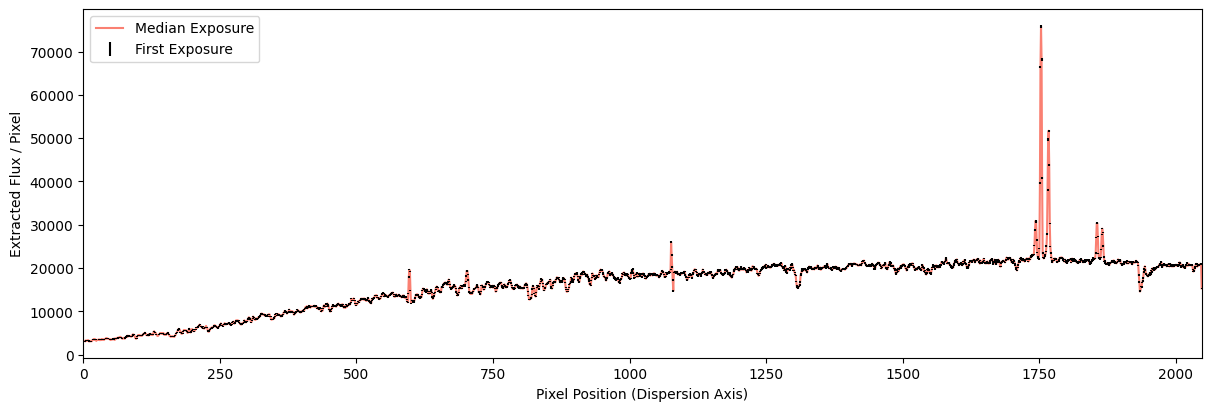

In [29]:
optimal_flux_m61, optimal_err_m61 = ss.horne_extraction(
    images = calibrated_scienceM61,
    backgrounds = backgrounds_m61[0],
    profile = "moffat",
    RN = 6.0,
    debug = True,
)

wiggles are absorption features from the billions of different types of stars.

In [30]:
backgrounds_NGC = ss.extract_background(
    images = scienceNCG,
    warp_model = warp_model,
    mask_region = (100, 210),
    #debug = True,
)
calibrated_scienceNCG = scienceNCG - backgrounds_NGC[0]

In [31]:
# Re-runs background extraction and collects additional returns
returned_data_NGC = ss.extract_background(
    images = scienceNCG,
    warp_model = warp_model,
    mask_region = (100,220),
    return_spectrum = True,
)

# Unpacks returned data into separate arrays
_NGC, background_effpix_NGC, background_flux_NGC, effpix_map_NGC = returned_data_NGC

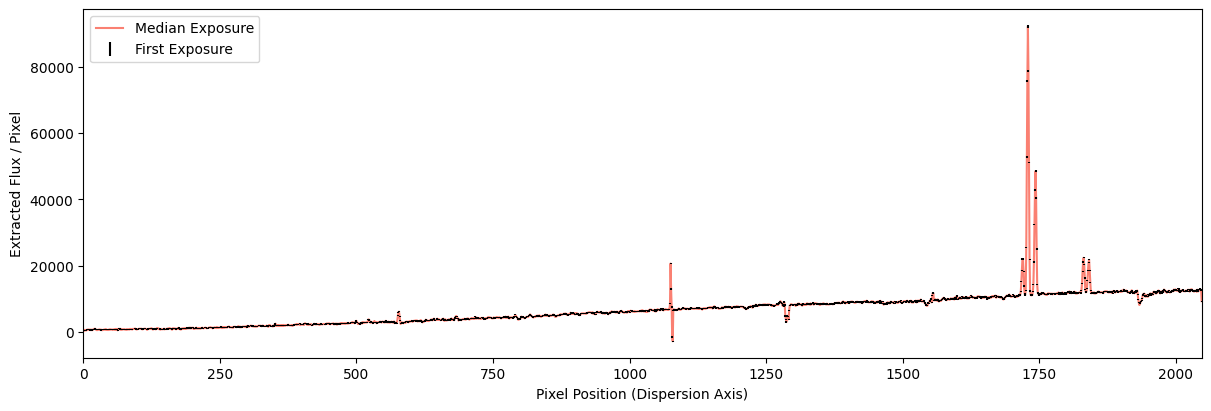

In [32]:
optimal_flux_NGC, optimal_err_NGC = ss.horne_extraction(
    images = calibrated_scienceNCG,
    backgrounds = backgrounds_NGC[0], 
    profile = "moffat",
    RN = 6.0,
    debug = True,
)

In [33]:
# getting rid of the fake emission line 

# M61
optimal_flux_m61[:, 1076:1081] = np.nan

# NGC
optimal_flux_NGC[:, 1074:1081] = np.nan

In [34]:
ne_lines = [
    5852.49, 5881.90, 5944.83, 6030.00, 6096.16, 6143.06, 6266.50, 6334.43, 6382.99, 6402.25,
    6506.53, 6598.95, 6678.28, 6717.04, 6929.47, 7032.41,
]

In [35]:
he_lines = [
    4471.48, 4713.15, 4921.93, 5015.68, 5875.62, 6678.15,
]

In [36]:
ar_lines= [
    4158.59, 4200.67, 4259.36, 4272.17, 4300.10, 4333.56, 4510.73, 5162.29, 5187.75, 5495.87,
    5558.70, 5606.73, 5650.70, 5888.58, 5912.09, 6032.13, 6384.72, 6416.31, 6677.28, 6752.83, 
    6871.29, 6937.66, 6965.43,
]

In [37]:
known_lines = combined_lines[1]

In [38]:
# arclamp_ne_lines, _ = ss.find_cal_lines(raw_arc_neon, std_variation=20, debug=True)

In [39]:
# wavecal_widget_ne = ss.WavecalWidget(
#     upper_lines = arclamp_ne_lines,
#     lower_lines = ne_lines,
# )

# wavecal_widget_ne.activate_widget()   #uncomment to interact with the widget

In [40]:
# paired_lines_ne = wavecal_widget_ne.final_lines 
# p_wavecal_ne = wavecal_widget_ne.p 
# pdr_wavecal_ne = wavecal_widget_ne.pdr 

In [41]:
# df = pd.DataFrame(paired_lines_ne)
# df.to_csv('paired_lines_ne.csv', index=False)
# df = pd.DataFrame(p_wavecal_ne)
# df.to_csv('p_wavecal_ne.csv', index=False)
# df = pd.DataFrame(pdr_wavecal_ne)
# df.to_csv('pdr_wavecal_ne.csv', index=False)

In [42]:
# arclamp_he_lines, _ = ss.find_cal_lines(raw_arc_helium, std_variation=20, debug=True)

In [43]:
# wavecal_widget_he = ss.WavecalWidget(
#     upper_lines = arclamp_he_lines,
#     lower_lines = he_lines,
# )

# wavecal_widget_he.activate_widget()   #uncomment to interact with the widget

In [44]:
# paired_lines_he = wavecal_widget_he.final_lines 
# p_wavecal_he = wavecal_widget_he.p 
# pdr_wavecal_he = wavecal_widget_he.pdr 

# df = pd.DataFrame(paired_lines_he)
# df.to_csv('paired_lines_he.csv', index=False)
# df = pd.DataFrame(p_wavecal_he)
# df.to_csv('p_wavecal_he.csv', index=False)
# df = pd.DataFrame(pdr_wavecal_he)
# df.to_csv('pdr_wavecal_he.csv', index=False)

In [45]:
# arclamp_ar_lines, _ = ss.find_cal_lines(raw_arc_argon, std_variation=10, debug=True)

In [46]:
# wavecal_widget_ar = ss.WavecalWidget(
#     upper_lines = arclamp_ar_lines,
#     lower_lines = ar_lines,
# )

# wavecal_widget_ar.activate_widget()   #uncomment to interact with the widget

In [47]:
# paired_lines_ar = wavecal_widget_ar.final_lines 
# p_wavecal_ar = wavecal_widget_ar.p 
# pdr_wavecal_ar = wavecal_widget_ar.pdr 

# df = pd.DataFrame(paired_lines_ar)
# df.to_csv('paired_lines_ar.csv', index=False)
# df = pd.DataFrame(p_wavecal_ar)
# df.to_csv('p_wavecal_ar.csv', index=False)
# df = pd.DataFrame(pdr_wavecal_ar)
# df.to_csv('pdr_wavecal_ar.csv', index=False)

In [48]:
# arclamp_lines, _ = ss.find_cal_lines(arclamp, std_variation=10, debug=True)

In [49]:
# wavecal_widget = ss.WavecalWidget(
#     upper_lines = known_lines,
#     lower_lines = arclamp_lines,
# )

# wavecal_widget.activate_widget()   #uncomment to interact with the widget

In [50]:
# paired_lines = wavecal_widget.final_lines # List of all paired lines
# p_wavecal = wavecal_widget.p # The final np.polynomial
# pdr_wavecal = wavecal_widget.pdr # The final derivative of np.polynomial

In [51]:
emission_lines_rest = [
    ("Hα",      6562.80),
    ("[N II]",  6548.05),
    ("[N II]",  6583.45),
    ("[HB]",    4861.00),
    ("[O III]", 4959.00),
    ("[O III]", 5007.00),
]

In [52]:
z_m61 = 0.005224
z_NGC = 0.000133

In [53]:
emission_lines_obs_m61 = [(name, wav * (1 + z_m61)) for name, wav in emission_lines_rest]
emission_lines_obs_NGC = [(name, wav * (1 + z_NGC)) for name, wav in emission_lines_rest]

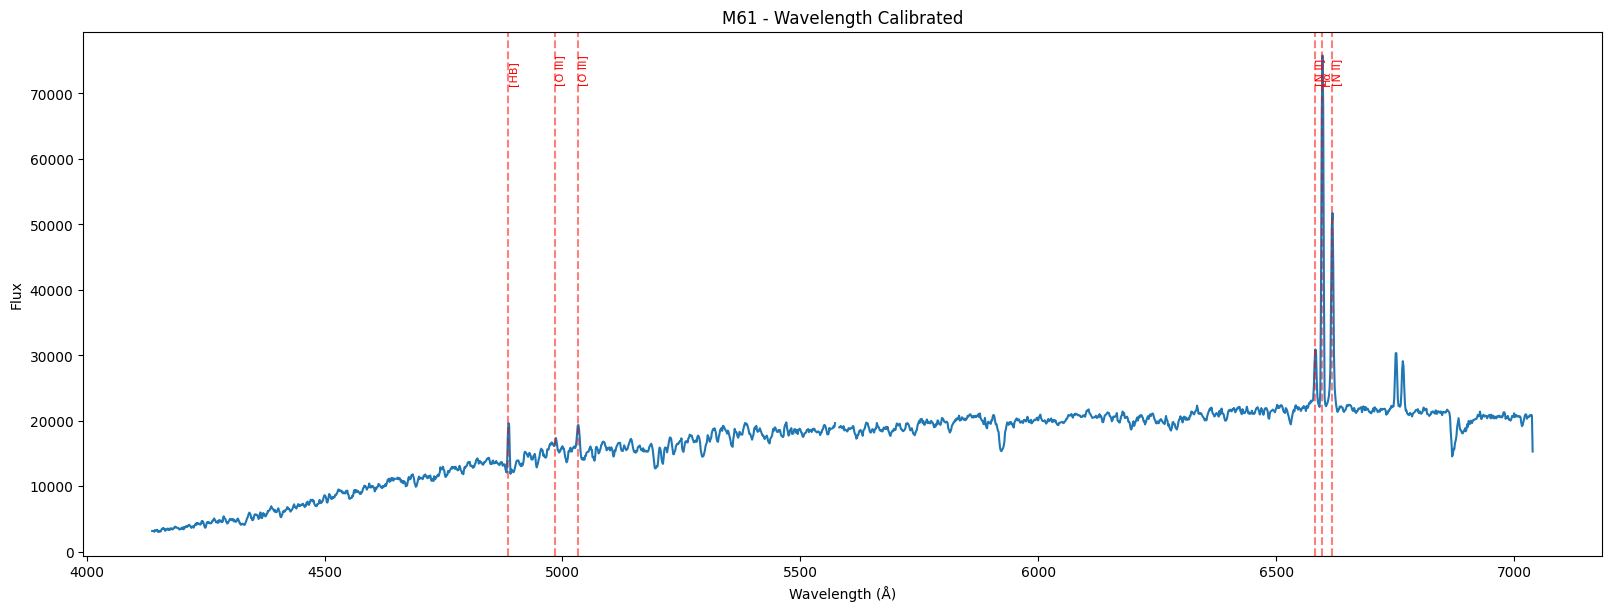

In [54]:
plt.figure(figsize=(16, 6))
plt.plot(wavelengths, np.squeeze(optimal_flux_m61))
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.title("M61 - Wavelength Calibrated")

for name, wav in emission_lines_obs_m61:
    plt.axvline(wav, color='red', linestyle='--', alpha=0.5)
    plt.text(wav, plt.ylim()[1]*0.9, name, rotation=90, fontsize=8, color='red')

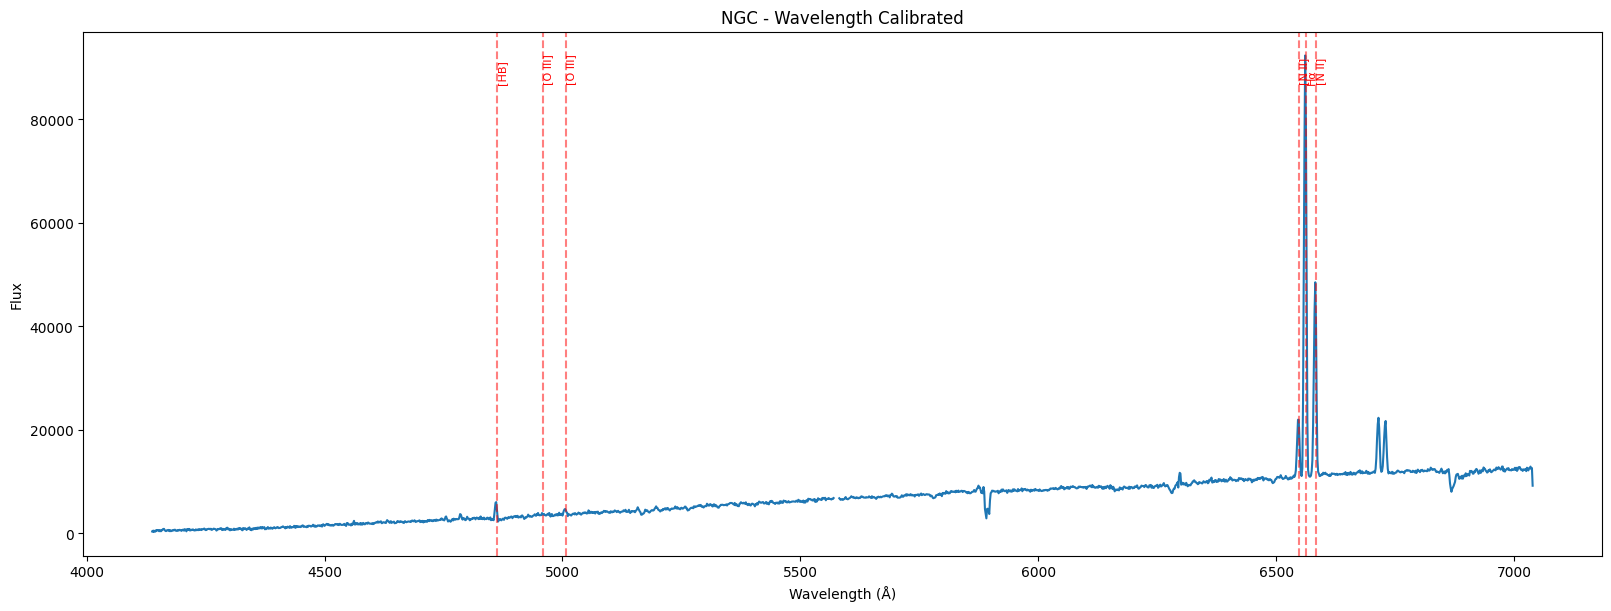

In [55]:
plt.figure(figsize=(16, 6))
plt.plot(wavelengths, np.squeeze(optimal_flux_NGC))
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.title("NGC - Wavelength Calibrated")

for name, wav in emission_lines_obs_NGC:
    plt.axvline(wav, color='red', linestyle='--', alpha=0.5)
    plt.text(wav, plt.ylim()[1]*0.9, name, rotation=90, fontsize=8, color='red')

In [56]:
# import ASDtools as asdt
# lines = asdt.NIST_lines(["O II", "He II"], lower_wavelength=4150*u.AA, upper_wavelength=7050*u.AA)
# lines.df

## Now Lets start flux analysis

In [64]:
# This a function useful for later

def load_STIS_spectra(
    name: str = None,
    filetype: str = "model",
    wavelength_bounds: tuple = None,
    debug: bool = False,
):
    # Loads FITS data for the specified star
    # Use `name` to build the file path instead of hardcoding it
    filepath = f"UT260324/flux_cal/{name}_stis_006.fits" if name else "UT260324/flux_cal/feige34_stis_006.fits"
    hdul = fits.open(filepath)

    # Unpacks spectral data
    data = hdul[1].data
    hdul.close()

    wavs = data["WAVELENGTH"] * u.AA

    # Generates mask for undesired wavelengths
    try:
        if wavelength_bounds is None:
            wavelength_bounds = [np.min(wavs), np.max(wavs)]
        mask = (wavelength_bounds[0] < wavs) & (wavs < wavelength_bounds[1])
        wavs = wavs[mask]
    except (TypeError, u.UnitConversionError):
        print(
            f"Wavelength bounds must be astropy.Quantities, not '{type(wavelength_bounds)}'"
        )
        return None

    if filetype == "model":
        cont = data["CONTINUUM"][mask] * u.erg / u.s / u.cm**2 / u.AA
        flux = data["FLUX"][mask] * u.erg / u.s / u.cm**2 / u.AA
        spec_data = [wavs, flux, cont]

    else:
        # BUG FIX: removed redundant re-assignment of `wavs` (already masked above)
        flux = data["FLUX"][mask] * u.erg / u.s / u.cm**2 / u.AA
        stat_err = data["STATERROR"][mask] * u.erg / u.s / u.cm**2 / u.AA
        syst_err = data["SYSERROR"][mask] * u.erg / u.s / u.cm**2 / u.AA  # BUG FIX: added [mask]
        fwhm = data["FWHM"][mask] * u.AA
        data_quality = data["DATAQUAL"][mask]
        exp_time = data["TOTEXP"][mask] * u.s
        spec_data = [wavs, flux, stat_err, syst_err, fwhm, data_quality, exp_time]

    if debug:
        fig, ax = plt.subplots(figsize=(12, 4))  # Avoid mutating global rcParams
        ax.plot(spec_data[0], spec_data[1], color="k")
        ax.set_xlim(np.min(spec_data[0].value), np.max(spec_data[0].value))
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("Wavelength [Angstroms]")
        ax.set_ylabel("Flux [flam]")
        plt.show()

    return spec_data

In [58]:
# Extract and subtract backround from feige34 image
backgrounds_feige34 = ss.extract_background(                                                        
      images=scienceFeige34,                                                                          
      warp_model=warp_model,                                                                          
      mask_region=(125, 175)                              
      # debug=True,                                                                                     
)                                                                                                   
calibrated_scienceFeige34 = scienceFeige34 - backgrounds_feige34[0]

In [59]:
# Re-runs background extraction and collects additional returns
returned_data_feige_34 = ss.extract_background(
    images = scienceFeige34,
    warp_model = warp_model,
    mask_region = (125, 175),
    return_spectrum = True,
)

# Unpacks returned data into separate arrays
_m61, background_effpix_m61, background_flux_m61, effpix_map_m61 = returned_data_m61

# I had to do this to get the horne extraction to work. To many 0s and neg pixels??
calibrated_clipped = np.where(                                            
      calibrated_scienceFeige34 + backgrounds_feige34[0] <= 0,              
      1e-10,                                                                
      calibrated_scienceFeige34,                                            
  )   

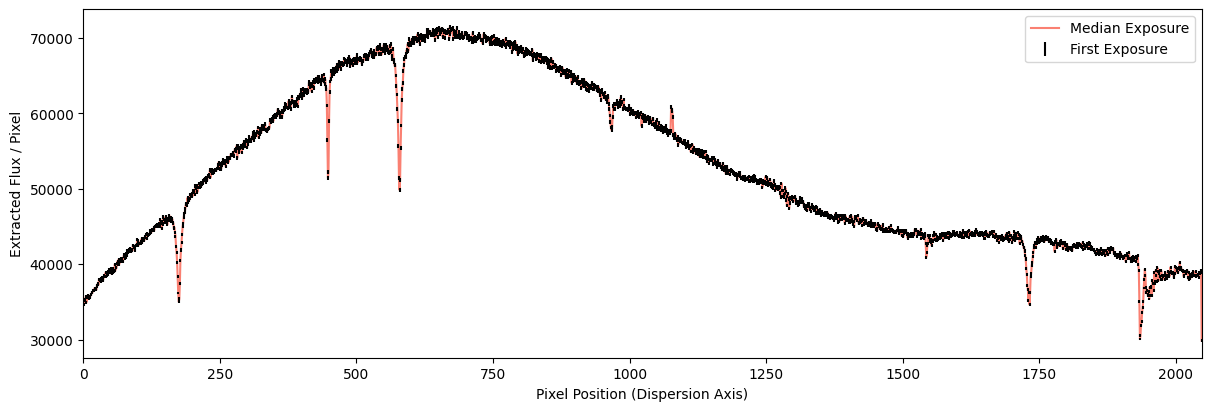

In [60]:
# Run Horne extraction to get 1D spectrum:
optimal_flux_feige34, optimal_err_feige34 = ss.horne_extraction(
      images=calibrated_clipped,
      backgrounds=backgrounds_feige34[0],
      profile="moffat",
      RN=6.0,
      debug=True
  )

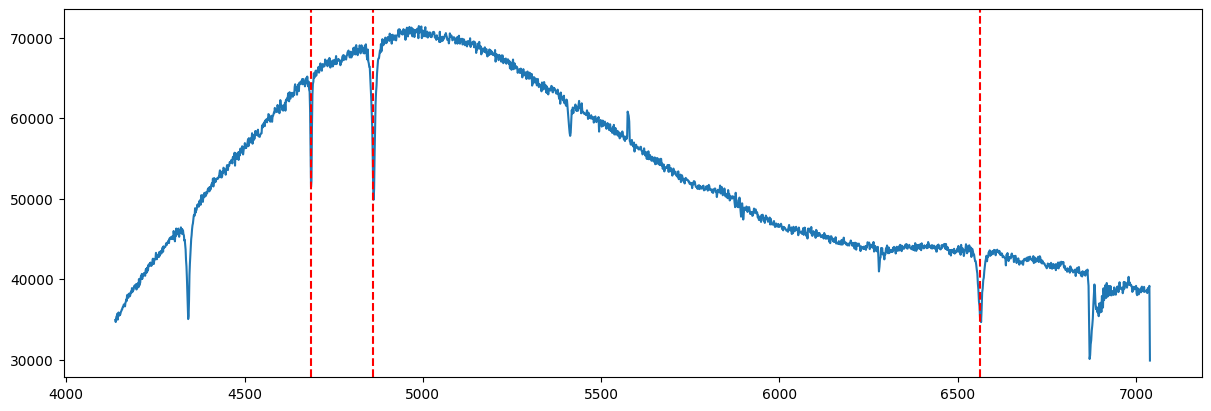

In [61]:
# Pixel to wavelength calibration for our data!
pixels = np.arange(len(optimal_flux_feige34))
wavs_feige34 = p_wavecal(pixel)

# Quick plot to check!
plt.plot(wavs_feige34, np.squeeze(optimal_flux_feige34))
plt.axvline(6563, color="red", linestyle = "--") # H alpha
plt.axvline(4686, color="red", linestyle = "--") # Helium II
plt.axvline(4861, color="red", linestyle = "--") # H beta

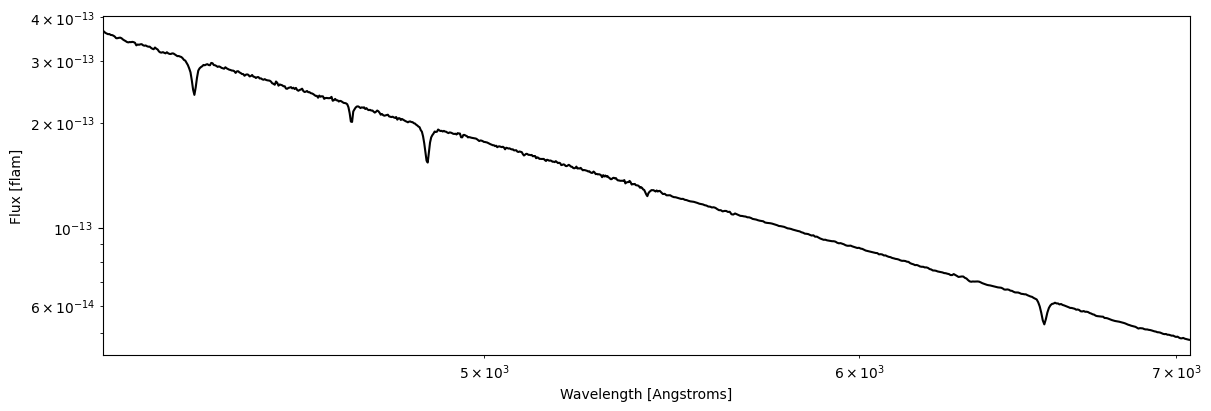

In [65]:
# LOAD IN TRUE SPECTRUM
wavs_stis, flux_stis, stat_err, syst_err, fwhm, dq, exptime = load_STIS_spectra(
    name="feige34",
    filetype="stis",
    wavelength_bounds=[4150, 7050] * u.AA,
    debug=True
)

# print(flux_stis)
# Units of ergs / Angstrom s cm^2

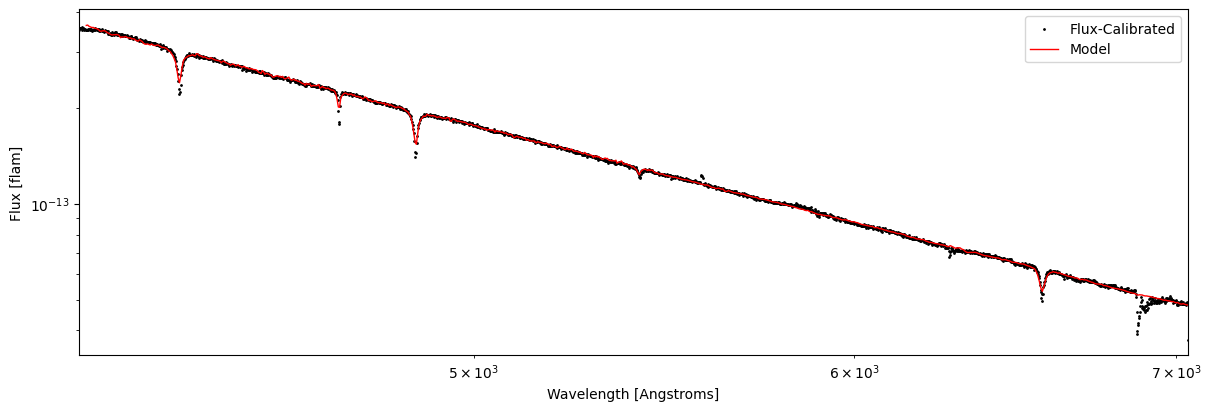

In [66]:
p_flux = ss.generate_flux_conversion(
    w_measured = wavs_feige34,
    w_model    = wavs_stis,
    f_measured = optimal_flux_feige34,
    f_model    = flux_stis,
    err        = optimal_err_feige34,
    debug      = True
)

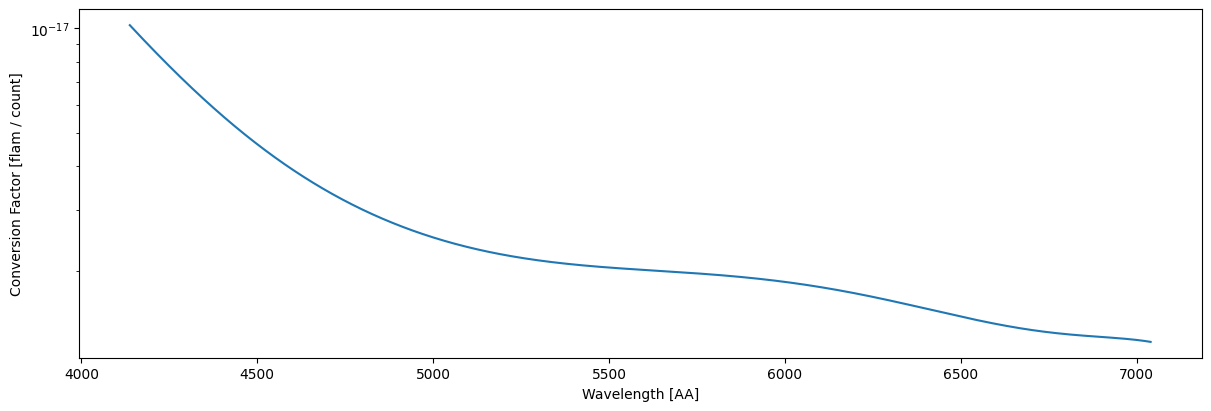

In [67]:
conversion = p_flux(wavs_feige34)

plt.plot(wavs_feige34, conversion)
plt.xlabel("Wavelength [AA]")
plt.ylabel("Conversion Factor [flam / count]")
plt.yscale("log")
plt.show()

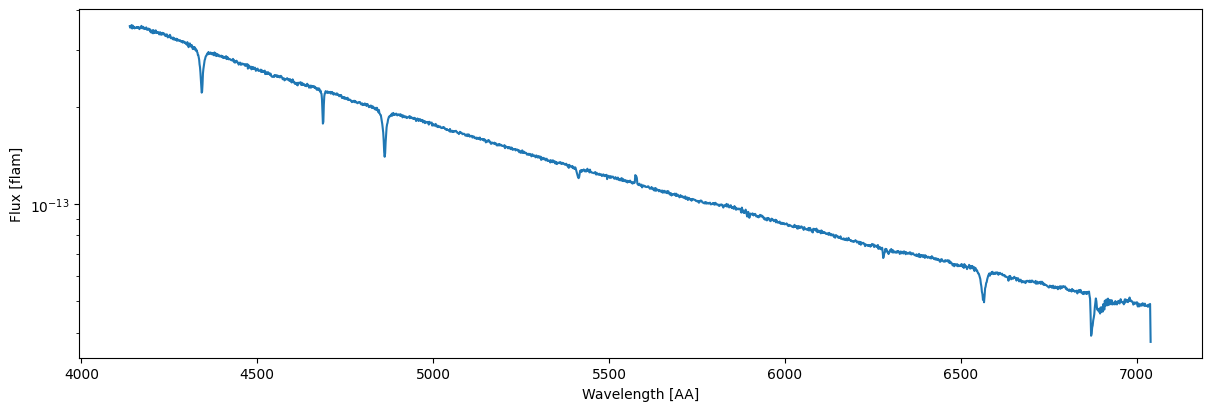

In [68]:
conversion = p_flux(wavs_feige34) * optimal_flux_feige34[0]

plt.plot(wavs_feige34, conversion)
plt.xlabel("Wavelength [AA]")
plt.ylabel("Flux [flam]")
plt.yscale("log")
plt.show()

Oh baby! Now we have it! p_flux(wavelenghts) * optimal_flux_<thing> with give us some calibrated flux

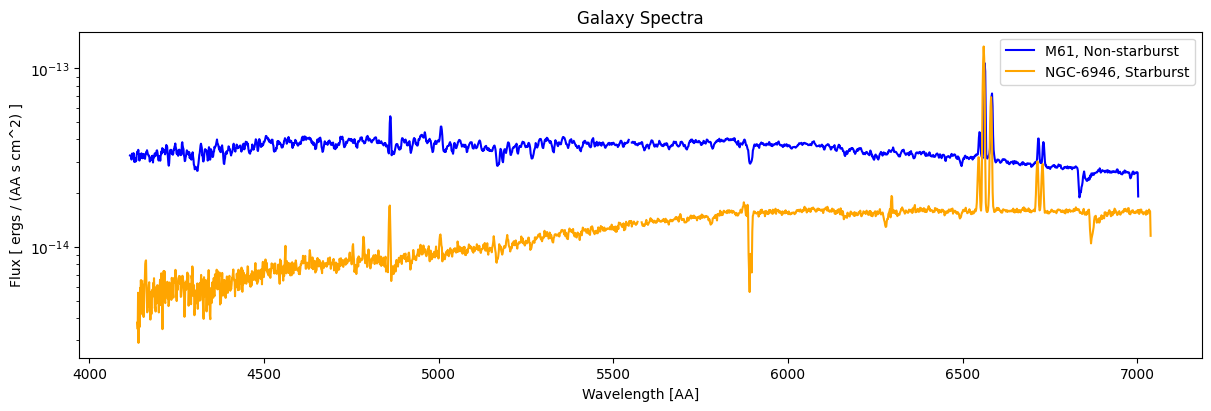

In [69]:
flux_calibrated_m61 = p_flux(wavelengths) * optimal_flux_m61[0]
flux_calibrated_ngc = p_flux(wavelengths) * optimal_flux_NGC[0]
err_calibrated_m61 = optimal_err_m61[0] * p_flux(wavelengths)
err_calibrated_ngc = optimal_err_NGC[0] * p_flux(wavelengths)

wavs_m61_rest = wavelengths / (1 + z_m61)
wavs_ngc_rest = wavelengths / (1 + z_NGC)

conversion_m61 = flux_calibrated_m61
conversion_NGC = flux_calibrated_ngc
plt.plot(wavs_m61_rest, conversion_m61, label = "M61, Non-starburst", color = "blue")
plt.plot(wavs_ngc_rest, conversion_NGC, label = "NGC-6946, Starburst", color = "orange")
plt.title("Galaxy Spectra")
plt.xlabel("Wavelength [AA]")
plt.ylabel("Flux [ ergs / (AA s cm^2) ]")
plt.yscale("log")
plt.legend()
plt.show()

## Lets start quantifying some lines

First, we have to start with a backround subtraction

In [70]:
spec_m61 = QTable(dict(
    wavelength = wavelengths,                   
    flux = flux_calibrated_m61,                 
    uncertainty = err_calibrated_m61       
))

spec_ngc = QTable(dict(
    wavelength = wavelengths,               
    flux = flux_calibrated_ngc,             
    uncertainty = err_calibrated_ngc        
))

In [71]:
# Ensure units are attached
wavs_m61 = spec_m61['wavelength'] / (1 + z_m61) * u.AA
flux_m61 = spec_m61['flux'] * (u.erg / u.s / u.cm**2 / u.AA)
err_m61  = spec_m61['uncertainty'] * (u.erg / u.s / u.cm**2 / u.AA)

wavs_ngc = spec_ngc['wavelength'] / (1 + z_NGC) * u.AA
flux_ngc = spec_ngc['flux'] * (u.erg / u.s / u.cm**2 / u.AA)
err_ngc  = spec_ngc['uncertainty'] * (u.erg / u.s / u.cm**2 / u.AA)

In [72]:
# Build Spectrum objects
spectrum_m61 = Spectrum(
    spectral_axis = wavs_m61,
    flux = flux_m61,
    uncertainty = StdDevUncertainty(err_m61)
)

spectrum_ngc = Spectrum(
    spectral_axis = wavs_ngc,
    flux = flux_ngc,
    uncertainty = StdDevUncertainty(err_ngc)
)

In [73]:
def plot_spectrum(spectrum, ax=None, **kw):
    import matplotlib.pyplot as plt

    if ax is None:
        ax = plt.gca()

    x = spectrum.spectral_axis
    flux = spectrum.flux

    ax.step(x, flux, where='mid', **kw)

    # uncertainty (optional)
    if hasattr(spectrum, "uncertainty") and spectrum.uncertainty is not None:
        try:
            uncertainty = spectrum.uncertainty.quantity
            ax.errorbar(x, flux, uncertainty,
                        linewidth=0, elinewidth=1,
                        color='gray', alpha=0.5)
        except Exception:
            pass

    ax.set_xlabel(f'Wavelength ({x.unit.to_string(format="latex_inline")})')
    ax.set_ylabel('Flux [ergs / (AA s cm^2)]')

In [74]:
# Masking out NaN and 0 values because specutils doesn't like that.
mask_m61 = np.isfinite(spectrum_m61.flux) & (spectrum_m61.flux > 0)

spectrum_m61 = Spectrum(
    spectral_axis = spectrum_m61.spectral_axis[mask_m61],
    flux = spectrum_m61.flux[mask_m61],
    uncertainty = StdDevUncertainty(
        spectrum_m61.uncertainty.quantity[mask_m61]
    )
)

mask_ngc = np.isfinite(spectrum_ngc.flux) & (spectrum_ngc.flux > 0)

spectrum_ngc = Spectrum(
    spectral_axis = spectrum_ngc.spectral_axis[mask_ngc],
    flux = spectrum_ngc.flux[mask_ngc],
    uncertainty = StdDevUncertainty(
        spectrum_ngc.uncertainty.quantity[mask_ngc]
    )
)

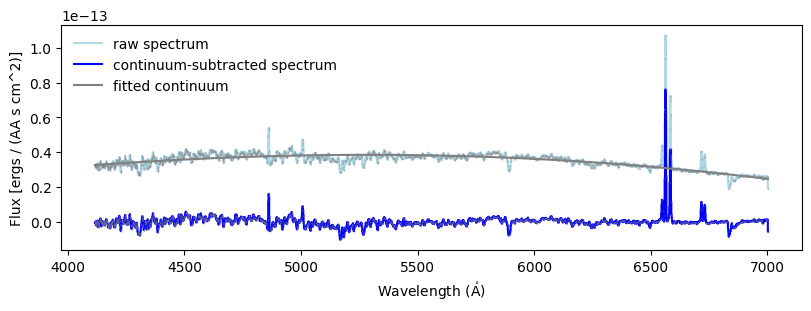

In [75]:
# Subtracting backround spectra
from specutils.fitting import fit_generic_continuum

# fit a continuum function, using a median to skip over 
continuum_function = fit_generic_continuum(spectrum_m61, median_window=201)

# define a pixel axis, estimate continuum at those pixels
w = spectrum_m61.spectral_axis
continuum = continuum_function(w)

# Subtract continum
continuum_subtracted_spectrum_m61 = spectrum_m61 - continuum 

# plot the 
fi = plt.figure(figsize=(8, 3), constrained_layout=True)
plot_spectrum(spectrum_m61, label='raw spectrum', color = "lightblue")
plot_spectrum(continuum_subtracted_spectrum_m61, label='continuum-subtracted spectrum', color = "blue")
plt.plot(w, continuum_function(w), label='fitted continuum', color = "gray")
plt.legend(frameon=False); 

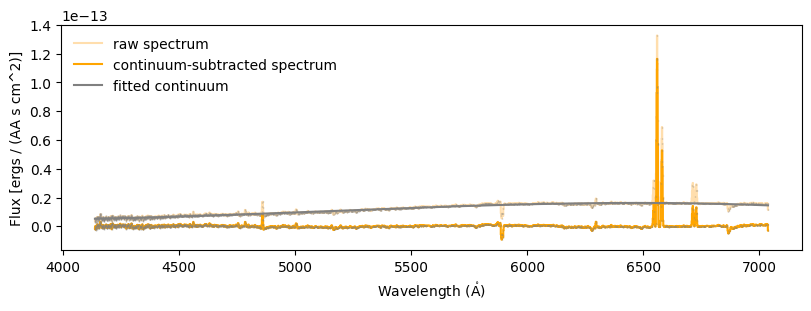

In [76]:
# Subtracting backround spectra
from specutils.fitting import fit_generic_continuum

# fit a continuum function, using a median to skip over 
continuum_function = fit_generic_continuum(spectrum_ngc, median_window=201)
continuum_function

# define a pixel axis, estimate continuum at those pixels
w = spectrum_ngc.spectral_axis
continuum = continuum_function(w)
continuum

continuum_subtracted_spectrum_ngc = spectrum_ngc - continuum 

# plot the 
fi = plt.figure(figsize=(8, 3), constrained_layout=True)
plot_spectrum(spectrum_ngc, label='raw spectrum', color="navajowhite")
plot_spectrum(continuum_subtracted_spectrum_ngc, label='continuum-subtracted spectrum', color="orange")
plt.plot(w, continuum_function(w), label='fitted continuum', color="gray")
plt.legend(frameon=False); 

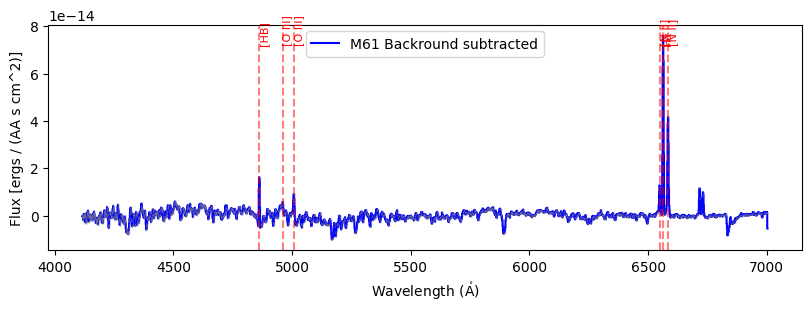

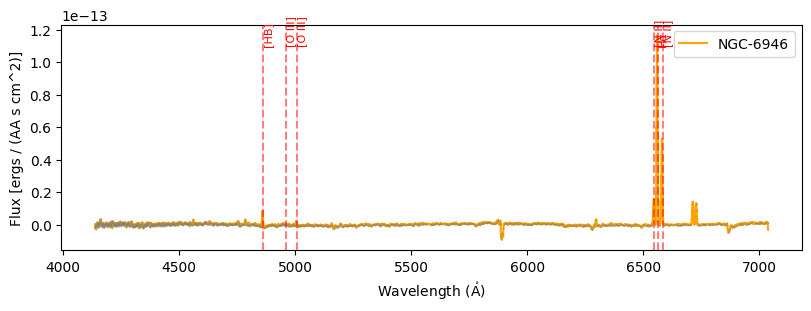

In [77]:
# plot the 
fi = plt.figure(figsize=(8, 3), constrained_layout=True)
plot_spectrum(continuum_subtracted_spectrum_m61, label='M61 Backround subtracted', color = "blue")
for name, wav in emission_lines_obs_NGC:
    plt.axvline(wav, color='red', linestyle='--', alpha=0.5)
    plt.text(wav, plt.ylim()[1]*0.9, name, rotation=90, fontsize=8, color='red')
plt.legend()
plt.show()

fi = plt.figure(figsize=(8, 3), constrained_layout=True)
plot_spectrum(continuum_subtracted_spectrum_ngc, label='NGC-6946', color = "orange")
for name, wav in emission_lines_obs_NGC:
    plt.axvline(wav, color='red', linestyle='--', alpha=0.5)
    plt.text(wav, plt.ylim()[1]*0.9, name, rotation=90, fontsize=8, color='red')
plt.legend()
plt.show()

Now, we are going to start quantifying lines:

In [78]:
h_beta = 4861
o_III = 5007
h_alpha = 6563
n_II = 6583

In [79]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from specutils import SpectralRegion
from specutils.manipulation import extract_region
from specutils.analysis import centroid, line_flux, fwhm, fwzi
from astropy.modeling import models
from specutils.fitting import fit_lines
from astropy.modeling.fitting import LevMarLSQFitter

def calculate_line_flux(galaxy, line_wav, window, line_name=None):
    line_pixel = line_wav * u.AA
    window = window * u.AA

    sub_region = SpectralRegion(line_pixel - window, line_pixel + window)
    sub_spectrum = extract_region(galaxy, sub_region)

    this_line_centroid = centroid(sub_spectrum)
    this_line_flux = line_flux(sub_spectrum)
    this_line_fwhm = fwhm(sub_spectrum)
    this_line_fwzi = fwzi(sub_spectrum)

    gaussian_initial_guess = models.Gaussian1D(
        mean=line_pixel,
        stddev=2 * u.AA,
        amplitude=np.max(sub_spectrum.flux)
    )

    # gaussian_optimized = fit_lines(sub_spectrum, gaussian_initial_guess)
    # I had to do this becase fit_lines wasn;t consistantly running for me :(
    fitter = LevMarLSQFitter()
    gaussian_optimized = fitter(gaussian_initial_guess,
                                sub_spectrum.spectral_axis,
                                sub_spectrum.flux)

    gaussian_line_centroid = gaussian_optimized.mean.quantity
    gaussian_line_sigma = gaussian_optimized.stddev.quantity
    gaussian_line_amplitude = gaussian_optimized.amplitude.quantity
    gaussian_line_fwhm = gaussian_optimized.fwhm

    gaussian_line_flux = gaussian_line_amplitude * np.sqrt(
        2 * np.pi * gaussian_line_sigma**2
    )

    fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
    if line_name is None:
        title = f"Line at {line_wav} Å"
    else:
        title = f"{line_name} ({line_wav} Å)"

    fig.suptitle(title, fontsize=16)
    (ax1, ax2, ax3), (ax4, ax5, ax6) = axes

    # Helper (ensures compatibility)
    def _plot(spec, ax, label=None, **kwargs):
        ax.plot(spec.spectral_axis, spec.flux, label=label, **kwargs)

    _plot(galaxy, ax1, label='full spectrum')
    ax1.axvline(line_pixel - window, color='red', linestyle='--')
    ax1.axvline(line_pixel + window, color='red', linestyle='--')
    ax1.set_title("Full Spectrum")
    ax1.legend()

    _plot(galaxy, ax2, alpha=0.3)
    _plot(sub_spectrum, ax2, label='line region')
    ax2.set_xlim(line_pixel - window*4, line_pixel + window*4)
    ax2.set_ylim(None, np.max(sub_spectrum.flux)*1.5)
    ax2.set_title("Zoomed Region")
    ax2.legend()

    _plot(sub_spectrum, ax3)
    ax3.axvline(this_line_centroid, color='gray', linestyle='--',
                label=f'centroid = {this_line_centroid:.2f}')
    ax3.set_title("Centroid")
    ax3.legend()

    _plot(sub_spectrum, ax4)

    ax4.fill_between(sub_spectrum.spectral_axis,
                     sub_spectrum.flux,
                     alpha=0.3,
                     label=f'flux = {this_line_flux:.2f}')

    # FWHM
    x = this_line_centroid + [-0.5, 0.5]*this_line_fwhm
    y = 0.5*np.max(sub_spectrum.flux)*np.ones(2)
    ax4.plot(x, y, label=f'FWHM = {this_line_fwhm:.2f}')

    # FWZI
    x = this_line_centroid + [-0.5, 0.5]*this_line_fwzi
    ax4.plot(x, np.zeros(2), label=f'FWZI')

    ax4.set_title("Line Properties")
    ax4.legend()

    _plot(sub_spectrum, ax5)

    ax5.plot(sub_spectrum.spectral_axis,
             gaussian_initial_guess(sub_spectrum.spectral_axis),
             linestyle='--',
             linewidth = 3,
             label='initial')

    ax5.plot(sub_spectrum.spectral_axis,
             gaussian_optimized(sub_spectrum.spectral_axis),
             label='fit')

    ax5.set_title("Gaussian Fit")
    ax5.legend()

    _plot(sub_spectrum, ax6)

    # numerical flux
    ax6.fill_between(sub_spectrum.spectral_axis,
                     sub_spectrum.flux,
                     alpha=0.3,
                     label=f'numerical = {this_line_flux:.2f}')

    # gaussian flux
    ax6.fill_between(sub_spectrum.spectral_axis,
                     gaussian_optimized(sub_spectrum.spectral_axis),
                     alpha=0.3,
                     label=f'gaussian = {gaussian_line_flux:.2f}')

    # centroids
    ax6.axvline(this_line_centroid, linestyle='--', label='centroid')
    ax6.axvline(gaussian_line_centroid, linestyle=':', label='gaussian centroid')

    # FWHM comparison
    x = this_line_centroid + [-0.5, 0.5]*this_line_fwhm
    y = 0.5*np.max(sub_spectrum.flux)*np.ones(2)
    ax6.plot(x, y, label='FWHM')

    x = gaussian_line_centroid + [-0.5, 0.5]*gaussian_line_fwhm
    ax6.plot(x, y*0.9, label='Gaussian FWHM')

    ax6.set_title("Final Comparison")
    ax6.legend()

    plt.show()

    return this_line_flux, gaussian_line_flux

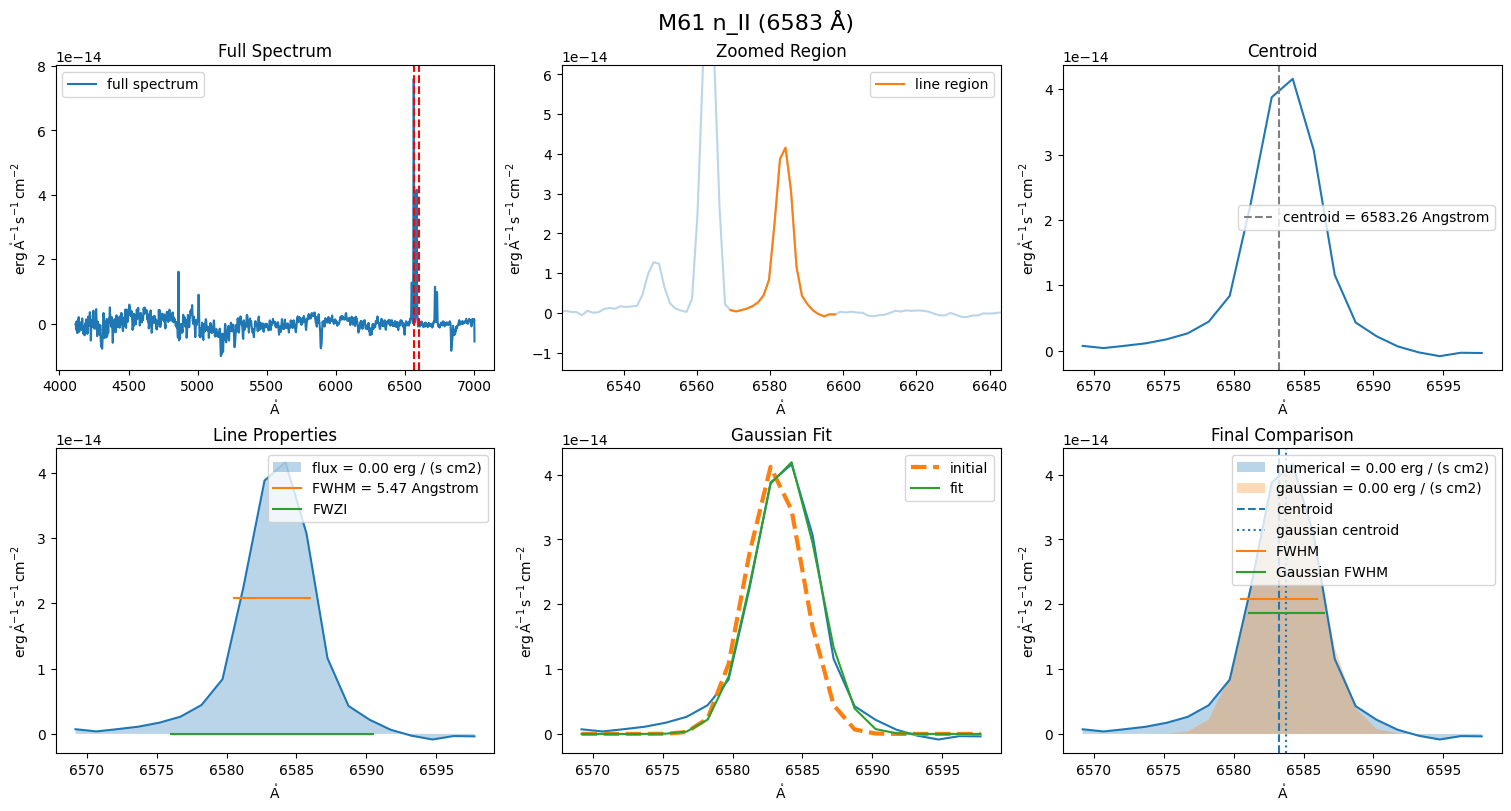

In [80]:
n_II_flux_m61 = calculate_line_flux(continuum_subtracted_spectrum_m61, n_II, 15, "M61 n_II")

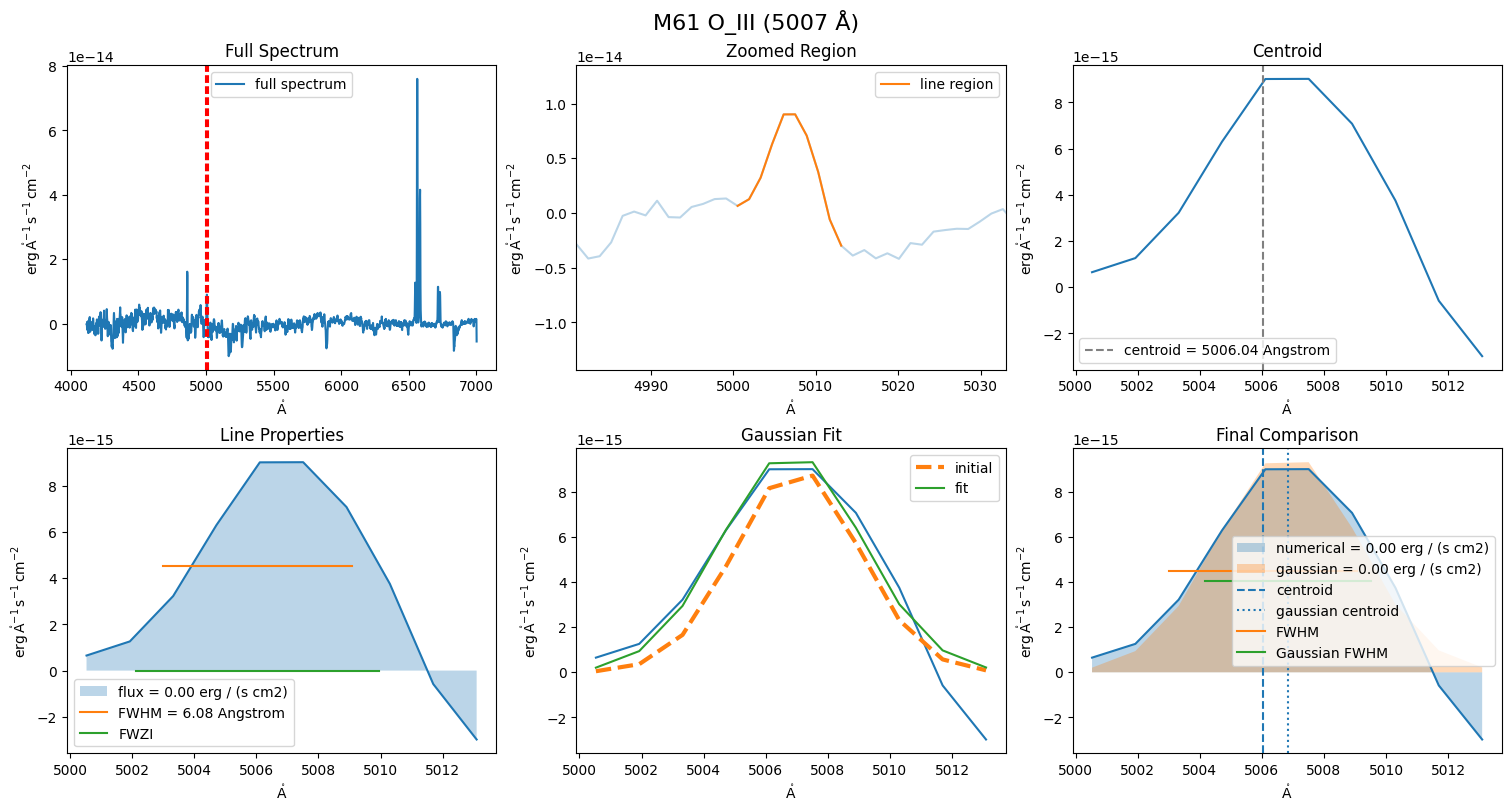

In [81]:
o_III_flux_m61 = calculate_line_flux(continuum_subtracted_spectrum_m61, o_III, 6.5, "M61 O_III")

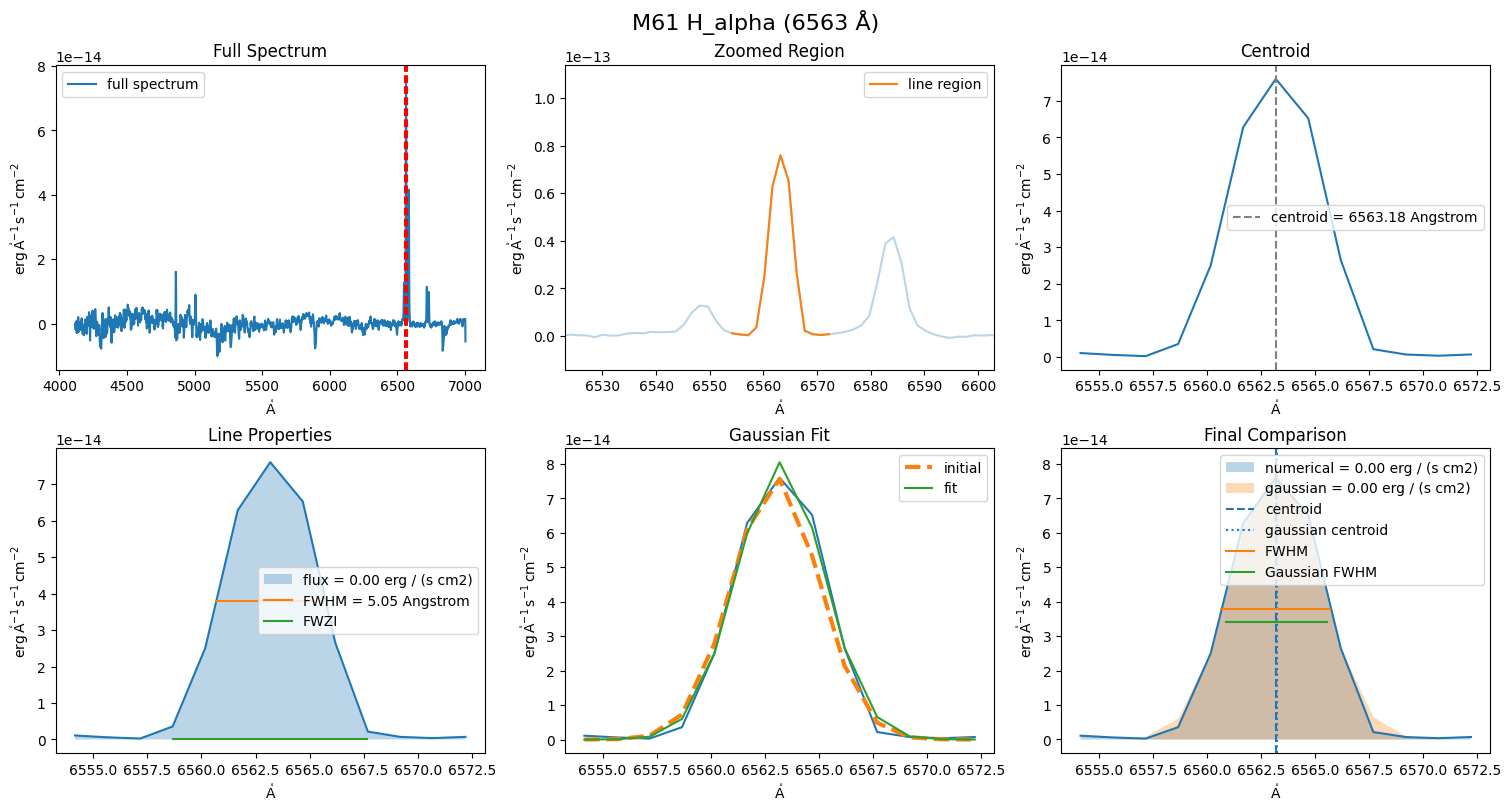

In [82]:
h_alpha_flux_m61 = calculate_line_flux(continuum_subtracted_spectrum_m61, h_alpha, 10, "M61 H_alpha")

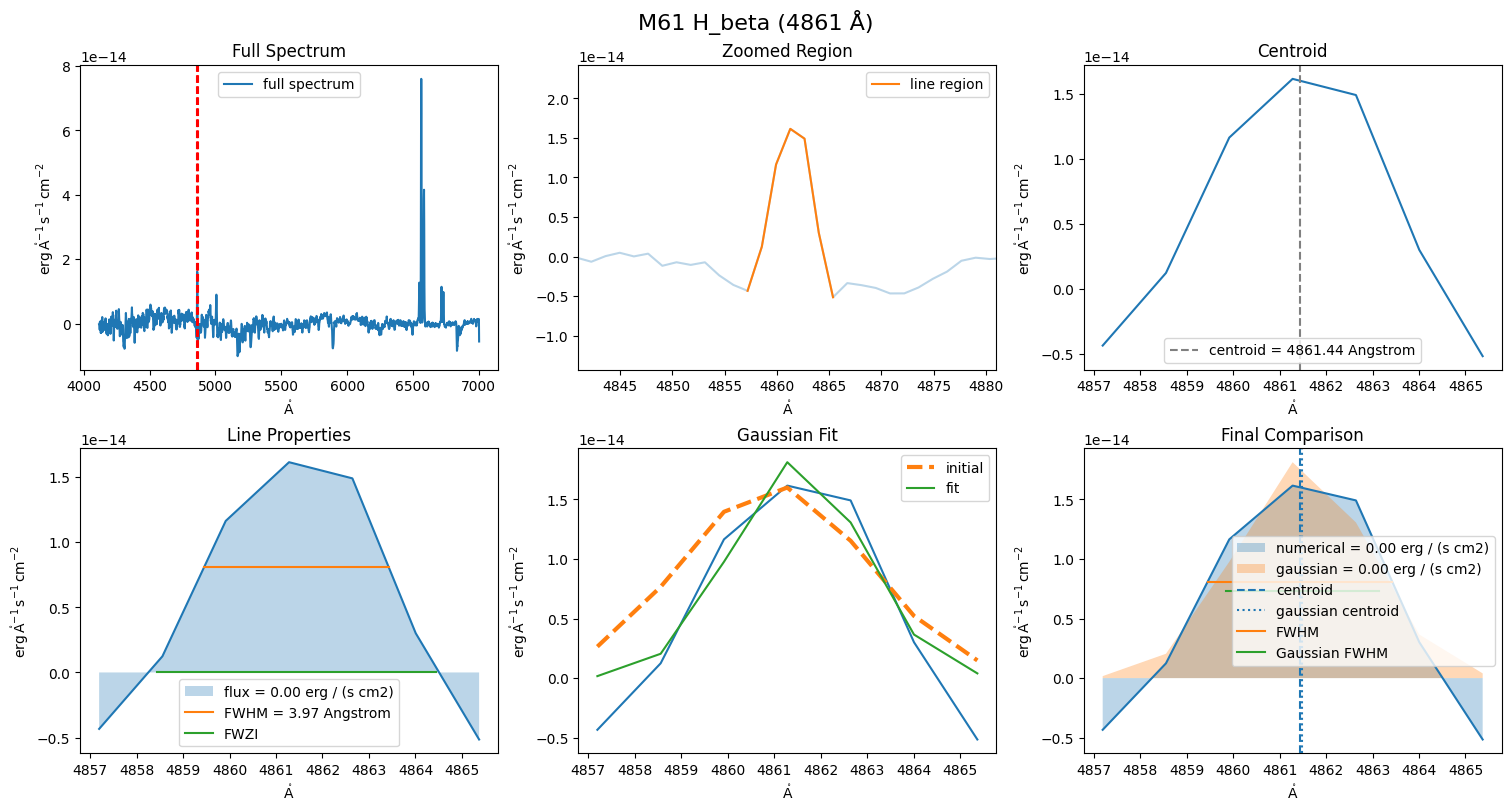

In [83]:
h_beta_flux_m61 = calculate_line_flux(continuum_subtracted_spectrum_m61, h_beta, 5, "M61 H_beta")

In [84]:
print("o_III_flux: ", o_III_flux_m61[1])
print("h_alpha_flux: ", h_alpha_flux_m61[1])
print("n_II_flux: ", n_II_flux_m61[1])
print("h_beta: ", h_beta_flux_m61[1])

o_III_flux:  5.545074902235717e-14 erg / (s cm2)
h_alpha_flux:  4.0261425395948536e-13 erg / (s cm2)
n_II_flux:  2.4415219264540195e-13 erg / (s cm2)
h_beta:  6.434515993109022e-14 erg / (s cm2)


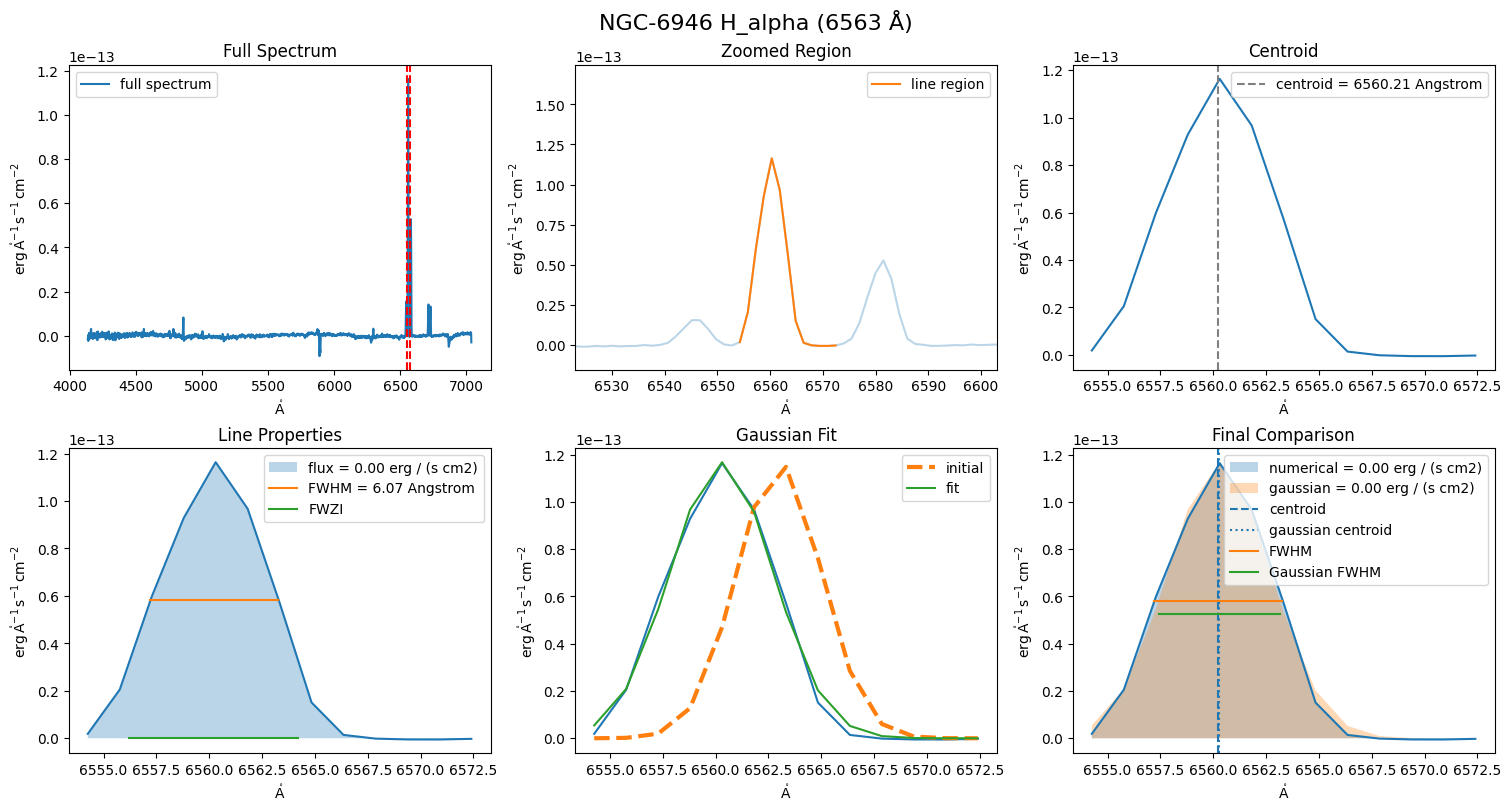

In [85]:
h_alpha_flux_ngc = calculate_line_flux(continuum_subtracted_spectrum_ngc, h_alpha, 10, "NGC-6946 H_alpha")

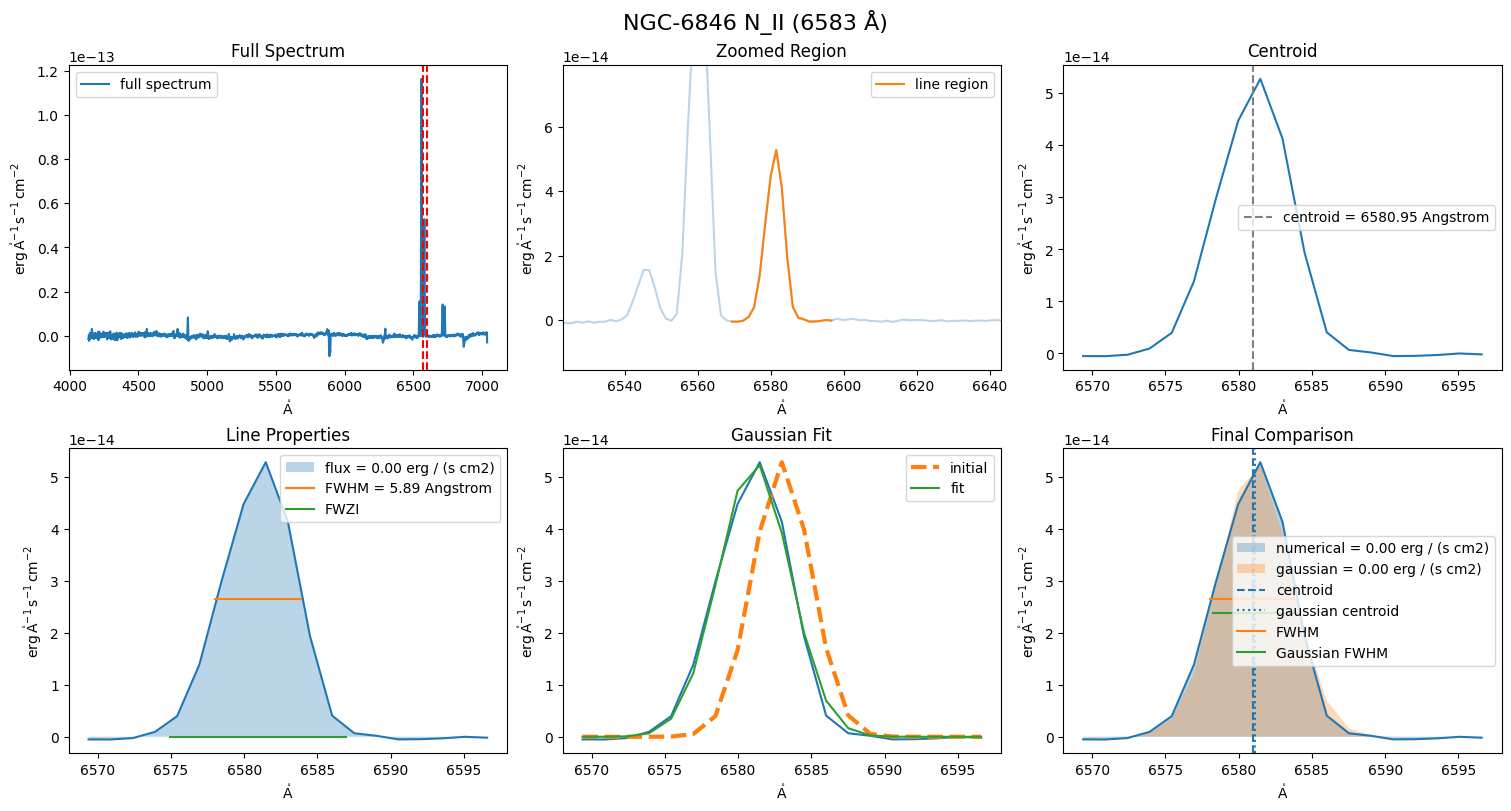

In [86]:
n_II_flux_ngc = calculate_line_flux(continuum_subtracted_spectrum_ngc, n_II, 15, "NGC-6846 N_II")

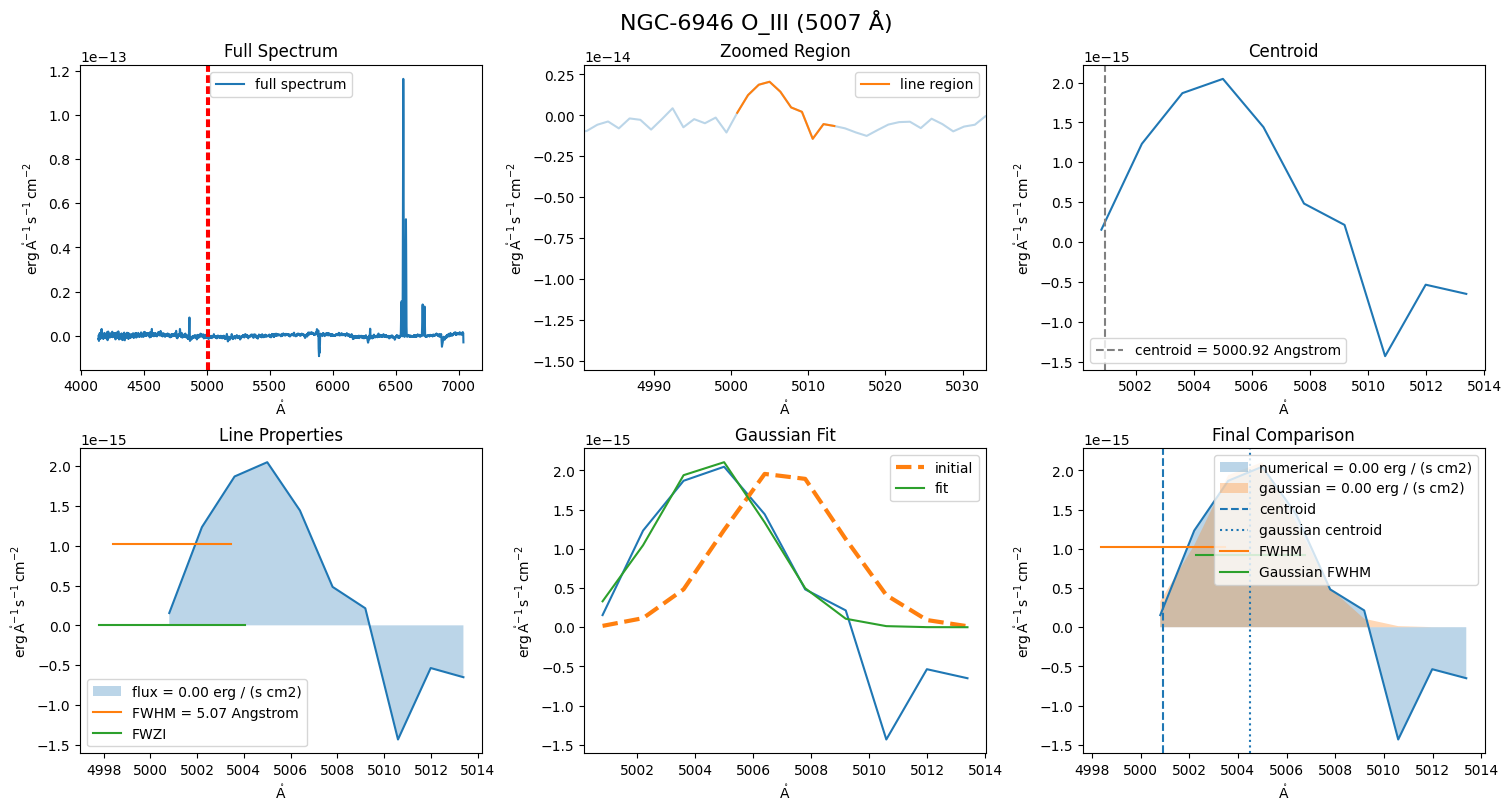

In [87]:
o_III_flux_ngc = calculate_line_flux(continuum_subtracted_spectrum_ngc, o_III, 6.5, "NGC-6946 O_III")

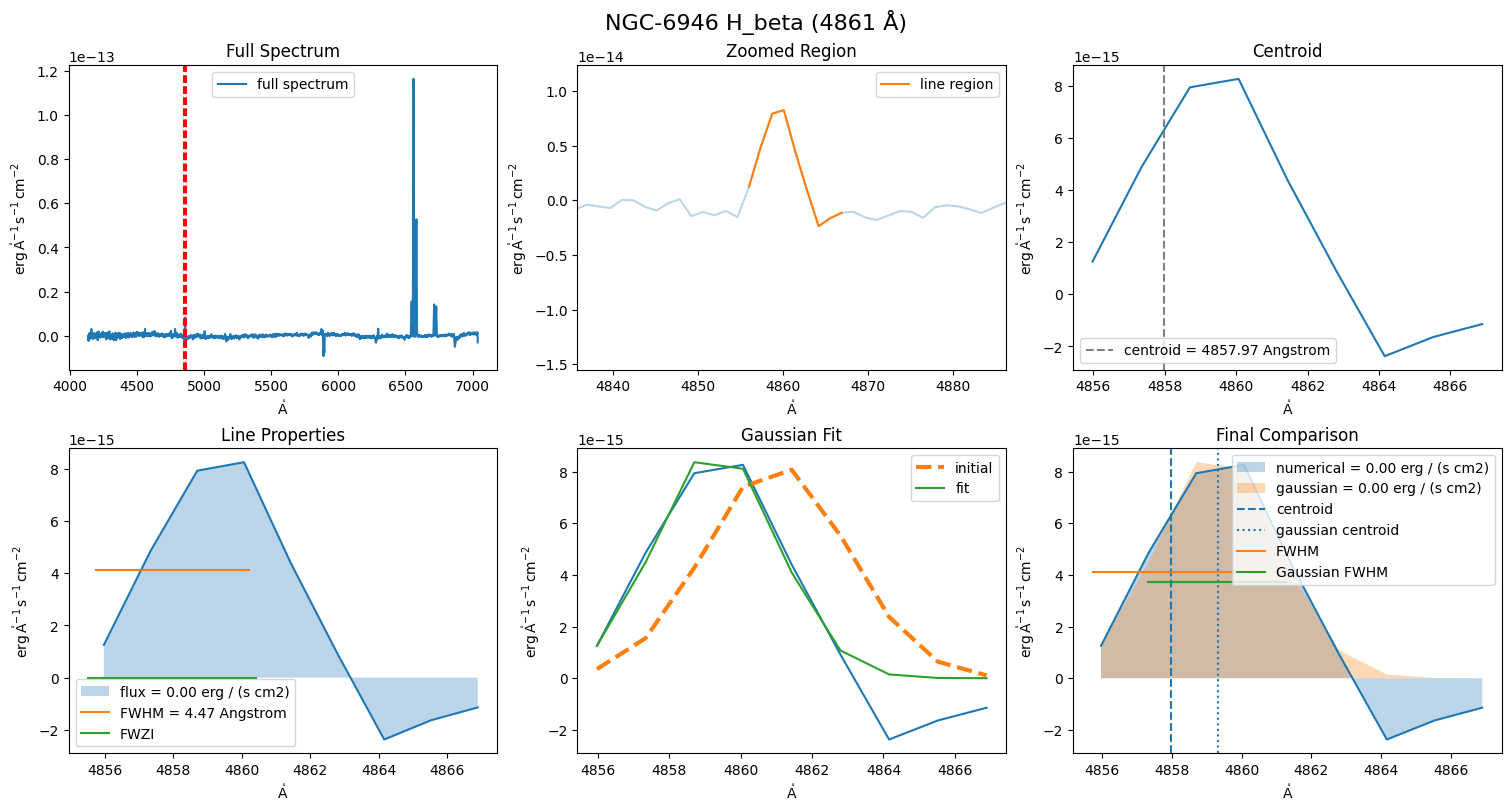

In [88]:
h_beta_flux_ngc = calculate_line_flux(continuum_subtracted_spectrum_ngc, h_beta, 6.3, "NGC-6946 H_beta")

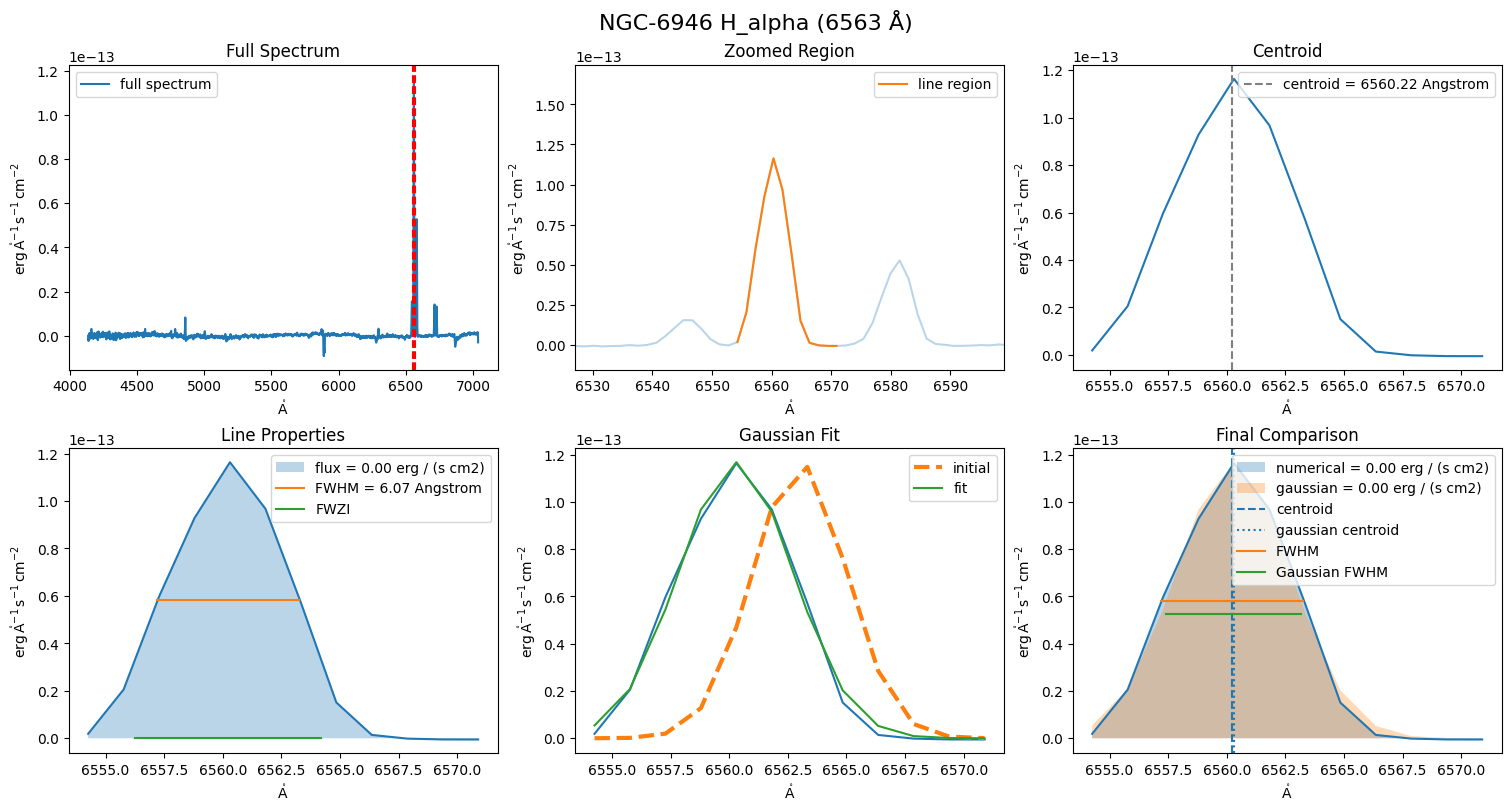

In [89]:
h_alpha_flux_ngc = calculate_line_flux(continuum_subtracted_spectrum_ngc, h_alpha, 9, "NGC-6946 H_alpha")

Fantastic! Now we are going to work on some BPT diagrams :)

In [90]:
o_III_over_h_beta_m61 = np.log10(o_III_flux_m61[1]/h_beta_flux_m61[1])
n_II_over_h_alpha_m61 = np.log10(n_II_flux_m61[1]/h_alpha_flux_m61[1])
n_II_over_h_alpha_ngc = np.log10(n_II_flux_ngc[1] / h_alpha_flux_ngc[1])
o_III_over_h_beta_ngc = np.log10(o_III_flux_ngc[1] / h_beta_flux_ngc[1])

# plt.scatter(n_II_over_h_alpha_ngc, o_III_over_h_beta_ngc, color = "orange", label="NGC-6946")
# plt.scatter(n_II_over_h_alpha_m61, o_III_over_h_beta_m61, color = "blue", label="M61")

In [91]:
import numpy as np
import scipy as sc
import pylab as plt

from astropy.io import fits

# Input data 
# FITS = fits.open('http://wwwmpa.mpa-garching.mpg.de/SDSS/DR7/Data/gal_line_dr7_v5_2.fit.gz') # Input data taken from XXX in its original format. 
# Download the data here: http://wwwmpa.mpa-garching.mpg.de/SDSS/DR7/Data/gal_line_dr7_v5_2.fit.gz

FITS = fits.open('gal_line_dr7_v5_2.fit.gz')  # Read the compress data
head      = FITS[1].data
infheader = head.columns

# If you need 
Hbeta  = FITS[1].data['H_BETA_FLUX']          # Reading the column with Hbeta line 
OIII   = FITS[1].data['OIII_5007_FLUX']       # Reading the column with OIII line
Halpha = FITS[1].data['H_ALPHA_FLUX']         # Reading the column with Halpha line
NII    = FITS[1].data['NII_6584_FLUX']        # Reading the column with NII line


f      = plt.figure(1)
xx     = np.log10(  NII / Halpha )      # log10(NII/Halpha)
yy     = np.log10( OIII /  Hbeta )      # log10(OIII/Hbeta)

ax                 = f.add_subplot(1,1,1)
bins_X, bins_Y     =  60, 60   # Define the number of bins in X- and Y- axis
Xmin, Xmax         = -1.5, 1.5   # Define the maximum and minimum limit in X-axis
Ymin, Ymax         = -1.5, 1.5   # Define the maximum and minimum limit in Y-axis
Nlevels            = 6           # Define the number of levels of isocontour


hist,xedges,yedges = np.histogram2d(xx,yy,bins=(bins_X, bins_Y),range=[[Xmin,Xmax],[Ymin,Ymax]])
masked             = np.ma.masked_where(hist==0, hist)
plotting           = ax.imshow(masked.T,extent=[Xmin, Xmax, Ymin, Ymax],interpolation='nearest',origin='lower',cmap=plt.cm.gray_r)
levels             = np.linspace(0., np.log10(masked.max()), Nlevels)[1:]
CS                 = ax.contour(np.log10(masked.T), levels, colors='k',linewidths=1,extent=[Xmin,Xmax,Ymin,Ymax])


# Kewley+01 ------------------------------------------
X = np.linspace(-1.5,0.3)
Y = (0.61/( X  - 0.47  )) + 1.19

# Schawinski+07 --------------------------------------
X3 = np.linspace(-0.180,1.5)
Y3 = 1.05*X3 + 0.45

# Kauffmann+03 ---------------------------------------
Xk = np.linspace(-1.5,0.)
Yk = 0.61/(Xk -0.05) + 1.3

# Regions --------------------------------------------
ax.plot(X,   Y, '-' , color='purple', label='Kewley+01'    ) # Kewley+01
# ax.plot(X3, Y3, '-', color='purple', label='Schawinski+07') # Schawinski+07
ax.plot(Xk, Yk, '--', color='purple', label='Kauffmann+03' ) # Kauffmann+03
ax.scatter(n_II_over_h_alpha_ngc, o_III_over_h_beta_ngc, color = "orange", label="NGC-6946")
ax.scatter(n_II_over_h_alpha_m61, o_III_over_h_beta_m61, color = "blue", label="M61")
xticks = np.arange(-1.5, 1.6, 0.5)
yticks = np.arange(-1.5, 1.6, 0.5)
ax.set_xticks(xticks)
ax.set_yticks(yticks)

# Axi name here ...
Nsize = 10
ax.set_xlabel(r'log([NII] $\lambda$ 6583/H$\alpha$)',fontsize=Nsize)
ax.set_ylabel(r'log([OIII] $\lambda$ 5007/H$\beta$)',fontsize=Nsize)
ax.tick_params(labelsize = Nsize)
ax.set_ylim(Ymin, Ymax)
ax.set_xlim(Xmin, Xmax)
ax.legend()

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'gal_line_dr7_v5_2.fit.gz'

In [ ]:
def compute_o3n2_metallicity(o_III_flux, h_beta_flux, n_II_flux, h_alpha_flux):

    # line ratios
    o_III_h_beta = o_III_flux / h_beta_flux
    n_II_h_alpha = n_II_flux / h_alpha_flux

    # O3N2 index
    o_III_n_II = np.log10(o_III_h_beta) - np.log10(n_II_h_alpha)

    # metallicity
    metallicity = 8.73 - 0.32 * o_III_n_II

    return o_III_n_II, metallicity

In [ ]:
o3n2_m61, metallicity_m61 = compute_o3n2_metallicity(
    o_III_flux_m61[1],
    h_beta_flux_m61[1],
    n_II_flux_m61[1],
    h_alpha_flux_m61[1]
)
# n_II_over_h_alpha_m61

print("[M61] o_III_n_II: ", o3n2_m61)
print("[M61] 12 + log(O/H): ", metallicity_m61)

o3n2_ngc, metallicity_ngc = compute_o3n2_metallicity(
    o_III_flux_ngc[1],
    h_beta_flux_ngc[1],
    n_II_flux_ngc[1],
    h_alpha_flux_ngc[1]
)
# n_II_over_h_alpha_ngc

print("[NGC-6946] o_III_n_II: ", o3n2_ngc)
print("[NGC-6946] 12 + log(O/H): ", metallicity_ngc)

[M61] o_III_n_II:  0.14876251245676503
[M61] 12 + log(O/H):  8.682395996013836
[NGC-6946] o_III_n_II:  -0.2066619905499416
[NGC-6946] 12 + log(O/H):  8.796131836975981


In [ ]:
# Loading SDSS data
hdul = fits.open('gal_line_dr7_v5_2.fit.gz')  # or whatever it's named
data = hdul[1].data

# clean data
ha = data['H_ALPHA_FLUX']
hb = data['H_BETA_FLUX']
o3 = data['OIII_5007_FLUX']
nii = data['NII_6584_FLUX']

mask = (
    (ha > 0) &
    (hb > 0) &
    (o3 > 0) &
    (nii > 0)
)

ha = ha[mask]
hb = hb[mask]
o3 = o3[mask]
nii = nii[mask]

o3n2_sdss = np.log10(o3 / hb) - np.log10(nii / ha)
metal_sdss = 8.73 - 0.32 * o3n2_sdss

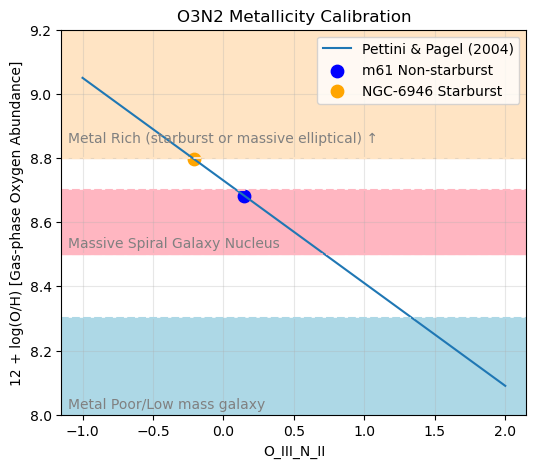

In [ ]:
# That is:
# 8.0-8.3 is metal-poor/ low mass galaxy
# 8.5-8.7 is typical massive spiral galaxy nucleus
# >8.8 means metal rich and likely starburst or massive elliptical 
# 8.69 is solar oxygen abundance

o3n2_grid = np.linspace(-1, 2, 100)
metallicity_grid = 8.73 - 0.32 * o3n2_grid

plt.figure(figsize=(6,5))
plt.plot(o3n2_grid, metallicity_grid, label='Pettini & Pagel (2004)')

plt.axhline(8.0, color="lightblue", linestyle= "--")
plt.axhline(8.3, color="lightblue", linestyle= "--")
plt.text(-1.1, 8.02, "Metal Poor/Low mass galaxy", color = "gray")
plt.axhspan(8.0, 8.3, color = "lightblue")
plt.axhline(8.5, color="lightpink", linestyle= "--")
plt.axhline(8.7, color="lightpink", linestyle= "--")
plt.text(-1.1, 8.52, "Massive Spiral Galaxy Nucleus", color = "gray")
plt.axhspan(8.5, 8.7, color = "lightpink")
plt.axhline(8.8, color="bisque", linestyle= "--")
plt.text(-1.1, 8.85, "Metal Rich (starburst or massive elliptical) ↑", color = "gray")
plt.axhspan(8.8, 9.2, color = "bisque")

plt.scatter(o3n2_m61, metallicity_m61, color='blue', s=80, label='m61 Non-starburst')
plt.scatter(o3n2_ngc, metallicity_ngc, color='orange', s=80, label='NGC-6946 Starburst')

# SDSS catalog arrays:
# plt.scatter(o3n2_sdss, metal_sdss, s=.4, alpha=0.2, color='black', label="SDSS Galaxy Data")

plt.legend()

plt.xlabel('O_III_N_II')
plt.ylabel('12 + log(O/H) [Gas-phase Oxygen Abundance]')
plt.title('O3N2 Metallicity Calibration')
plt.ylim(8.0, 9.2)
plt.legend()
plt.grid(alpha=0.3)

plt.show()